In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix


In [6]:
# Load the dataset
df=pd.read_csv('/workspaces/Telecom-Churn-Prediction/data/teleco_churn.csv')
# Display the first few rows of the dataset
print(df.head())


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [7]:
#check for missing values
print(df.isnull().sum()) # no missing values in the dataset


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [9]:
df.dtypes 

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [11]:
# type of TotalCharges is object, we need to convert it to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [12]:
# remove customerID column as it is not useful for prediction
df.drop('customerID', axis=1, inplace=True)

In [13]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [17]:
# encoding categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True


In [37]:
# remove lines with Nan values in TotalCharges
df_encoded.dropna(subset=['TotalCharges'], inplace=True)


In [38]:
# Data distribution 
print(f"Number of churned customers: {df[df['Churn'] == 'Yes'].shape[0]}")
print(f"Number of non-churned customers: {df[df['Churn'] == 'No'].shape[0]}")

Number of churned customers: 1869
Number of non-churned customers: 5174


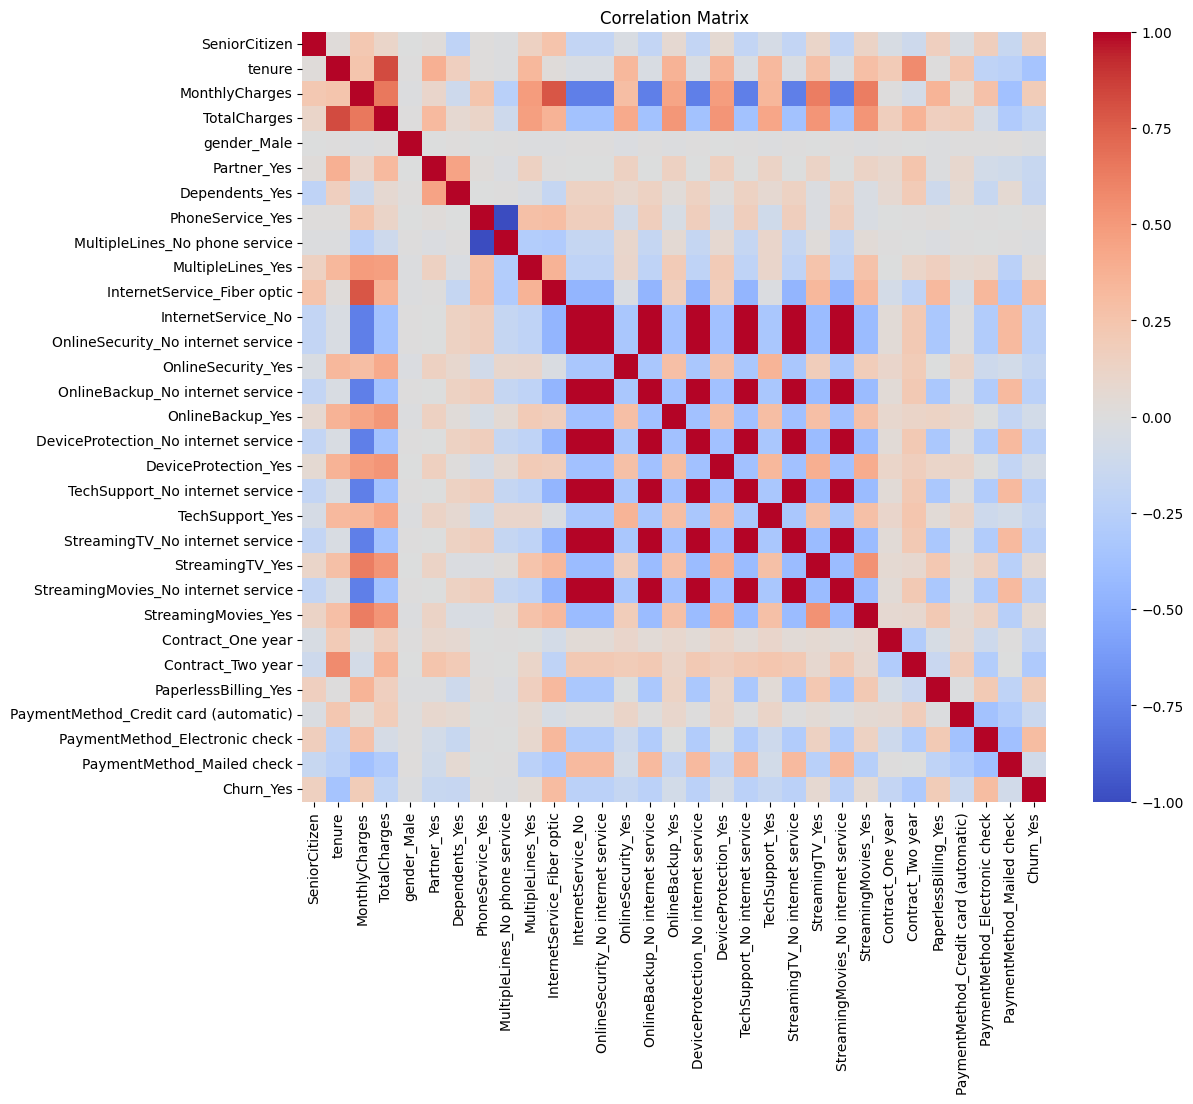

In [39]:
# correlation matrix
plt.figure(figsize=(12,10))
sns.heatmap(df_encoded.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [50]:
# list of features with abs(correlation) greater than 0.3 with Churn
correlation_threshold = 0.2
correlation_with_churn = df_encoded.corr()['Churn_Yes'].abs()
important_features = correlation_with_churn[correlation_with_churn > correlation_threshold].index.tolist()
print("Important features based on correlation with Churn:")
print(important_features)


Important features based on correlation with Churn:
['tenure', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineBackup_No internet service', 'DeviceProtection_No internet service', 'TechSupport_No internet service', 'StreamingTV_No internet service', 'StreamingMovies_No internet service', 'Contract_Two year', 'PaymentMethod_Electronic check', 'Churn_Yes']


/tmp/ipykernel_2656/3637530675.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=["object"]).columns.tolist()


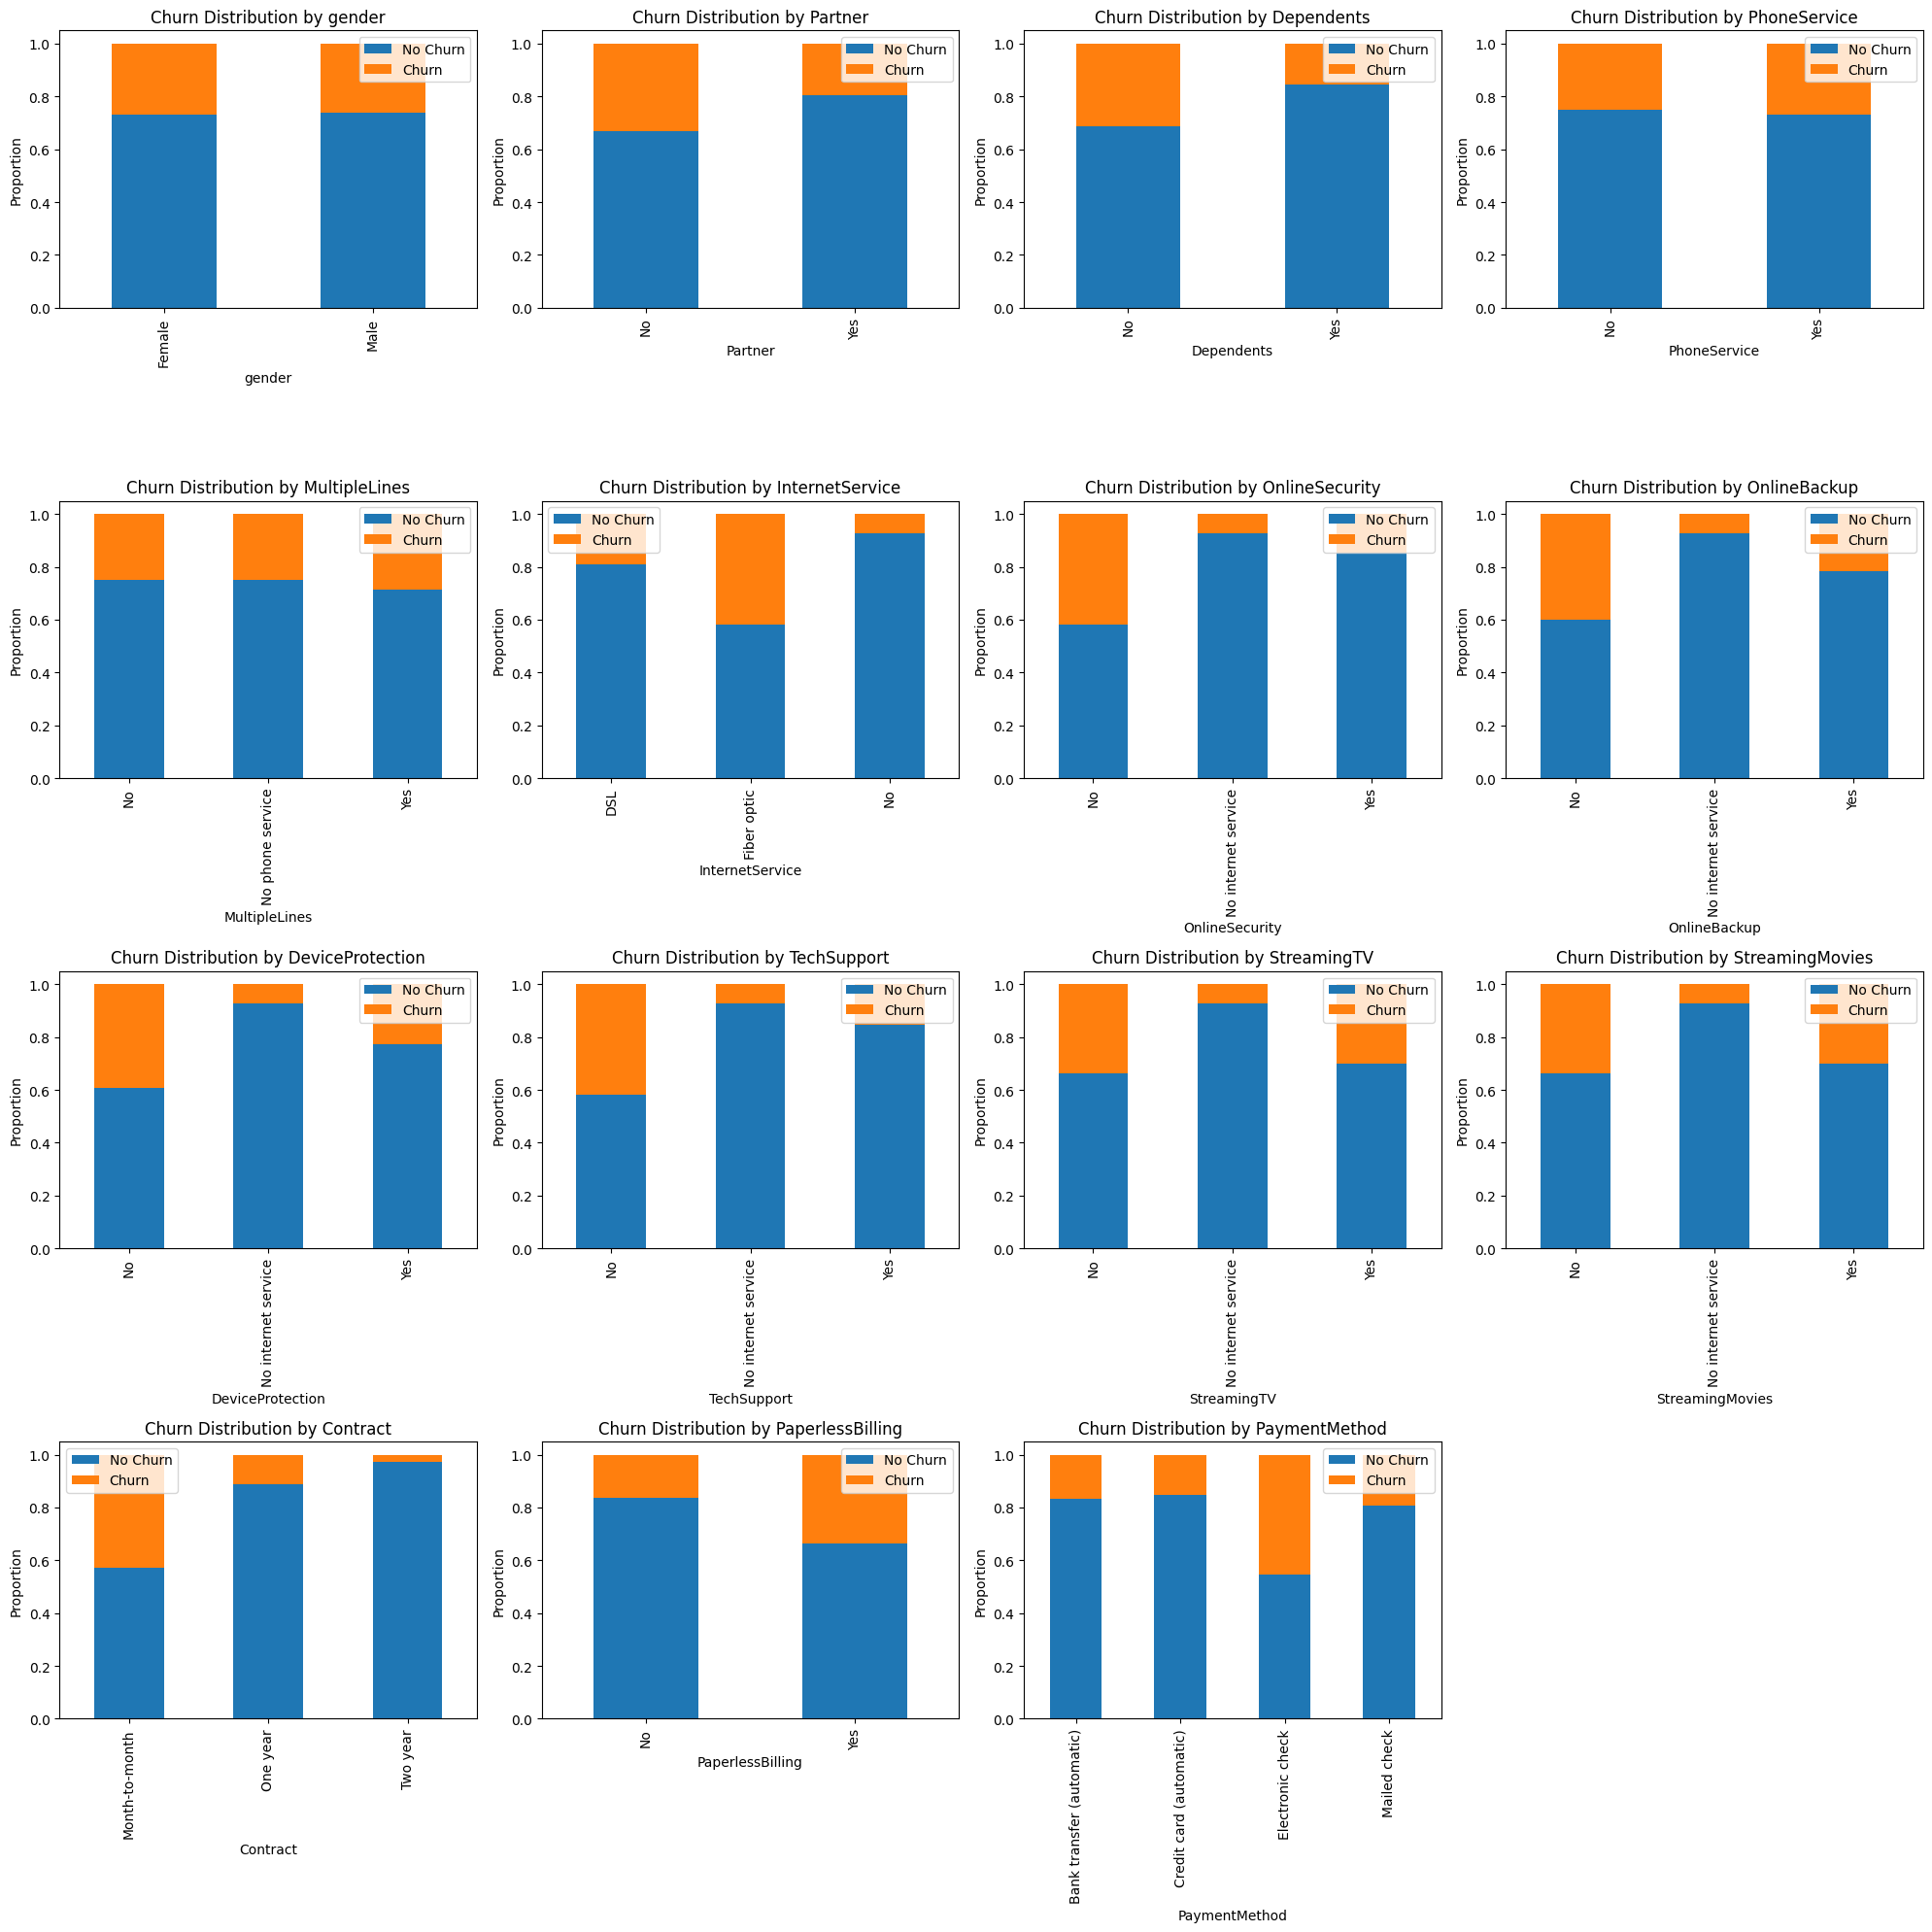

In [30]:
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()
categorical_features.remove("Churn")

numerical_features = df.select_dtypes(include=["int64","float64"]).columns.tolist()

# churn probability by categorical features all in one figure
ncols = 4
nrows = (len(categorical_features) + ncols - 1) // ncols  # Ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 5 * nrows))

axes = axes.flatten()  # Flatten to 1D array for easy indexing

for i, feature in enumerate(categorical_features):
    churn_rate = pd.crosstab(
        df[feature],
        df["Churn"],
        normalize="index"
    )

    churn_rate.plot(
        kind="bar",
        stacked=True,
        ax=axes[i]
    )

    axes[i].set_title(f"Churn Distribution by {feature}")
    axes[i].set_ylabel("Proportion")
    axes[i].set_xlabel(feature)
    axes[i].legend(["No Churn", "Churn"])

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

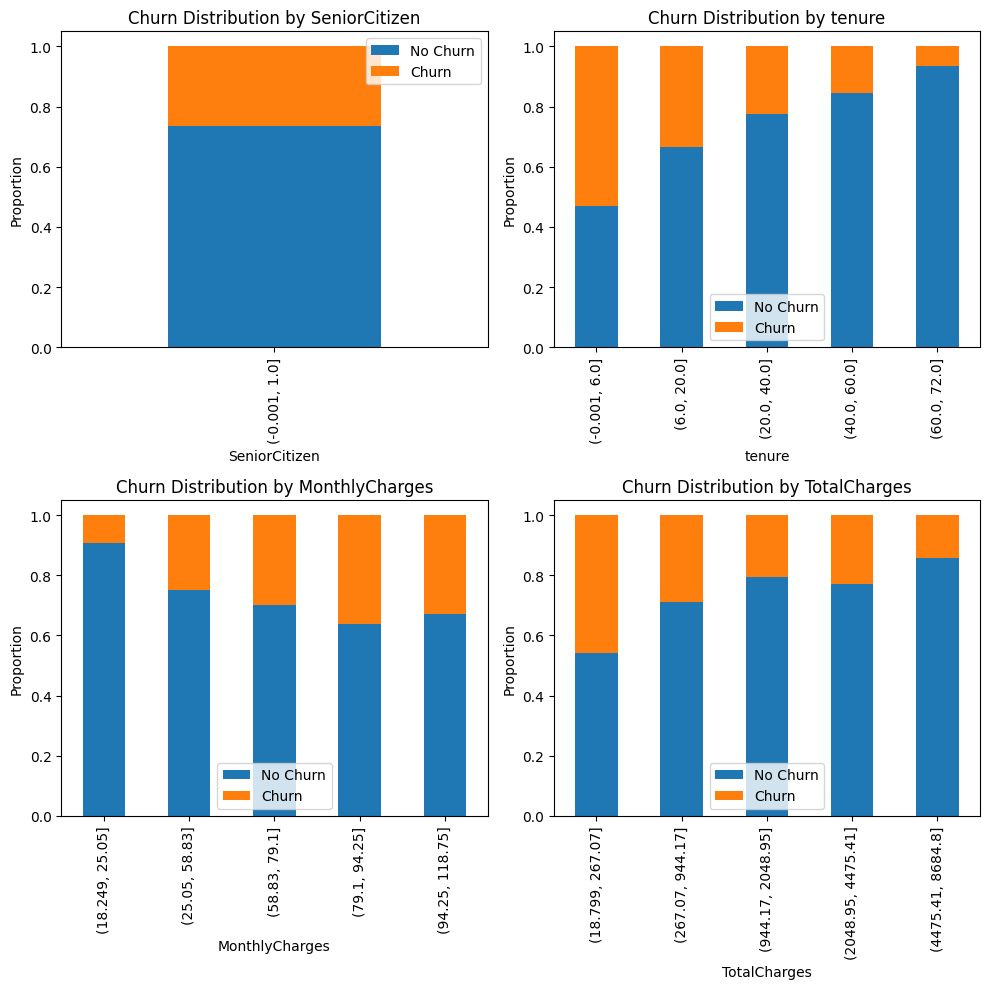

In [31]:
# churn probability by numerical features
ncols = 2
nrows = (len(numerical_features) + ncols - 1) // ncols  # Ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(10, 5 * nrows))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    df["binned"] = pd.qcut(df[feature], q=5, duplicates="drop")

    churn_rate = pd.crosstab(
        df["binned"],
        df["Churn"],
        
        normalize="index"
    )

    churn_rate.plot(
        kind="bar",
        stacked=True,
        ax=axes[i]
    )
    
    axes[i].set_title(f"Churn Distribution by {feature}")
    axes[i].set_ylabel("Proportion")
    axes[i].set_xlabel(feature)
    axes[i].legend(["No Churn", "Churn"])
    df.drop("binned", axis=1, inplace=True)
plt.tight_layout()
plt.show()



In [51]:
# Feature importance using mutual information
from sklearn.feature_selection import mutual_info_classif

# Prepare data
y = df_encoded['Churn_Yes']
X = df_encoded.drop('Churn_Yes', axis=1)

# Compute mutual information scores
mi_scores = mutual_info_classif(X, y, random_state=42)

# Create a series for easy viewing
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

print("Top 10 features signaling churn (by mutual information):")
print(mi_series.head(10))

Top 10 features signaling churn (by mutual information):
tenure                                0.075402
Contract_Two year                     0.062579
InternetService_Fiber optic           0.052035
MonthlyCharges                        0.049388
TotalCharges                          0.043091
PaymentMethod_Electronic check        0.043016
StreamingTV_No internet service       0.036332
TechSupport_No internet service       0.035248
OnlineSecurity_No internet service    0.034464
OnlineBackup_No internet service      0.030587
dtype: float64


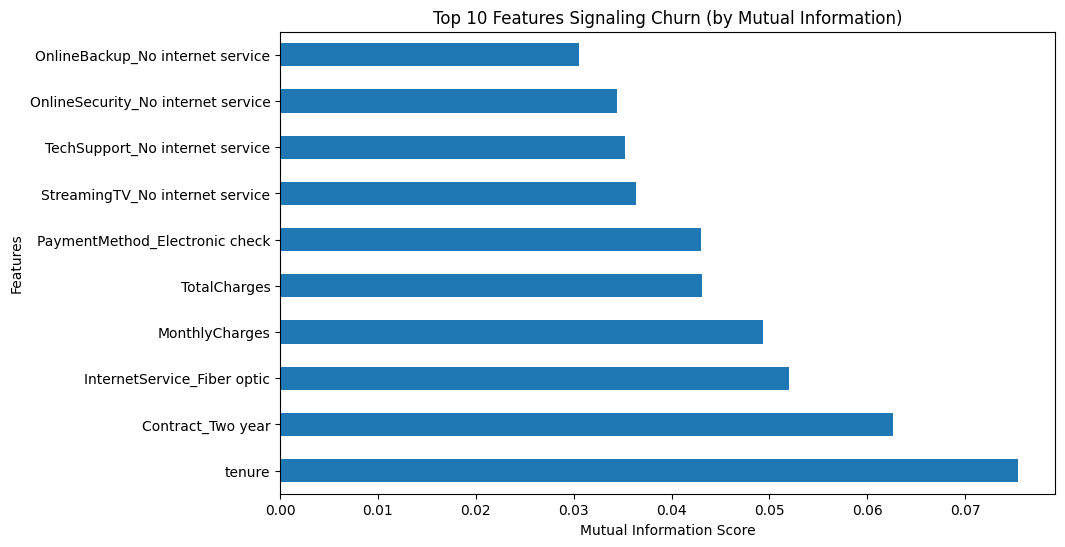

In [52]:
# Visualize top 10 features by mutual information
mi_series.head(10).plot(kind='barh', figsize=(10,6))
plt.title('Top 10 Features Signaling Churn (by Mutual Information)')
plt.xlabel('Mutual Information Score')
plt.ylabel('Features')
plt.show()

In [ ]:
# Chi-Square test of independence for categorical features
from scipy.stats import chi2_contingency
# p-value threshold for significance
p_value_threshold = 0.05

# print significant features based on chi-square test
print("Significant features based on Chi-Square test of independence:")
for feature in categorical_features:
    contingency_table = pd.crosstab(df[feature], df['Churn'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    if p < p_value_threshold:
        print(f"{feature}: p-value = {p:.4f} (Significant)")
    else:
        print(f"{feature}: p-value = {p:.4f} (Not Significant)")
        

    

 

Significant features based on Chi-Square test of independence:
gender: p-value = 0.4866 (Not Significant)
Partner: p-value = 0.0000 (Significant)
Dependents: p-value = 0.0000 (Significant)
PhoneService: p-value = 0.3388 (Not Significant)
MultipleLines: p-value = 0.0035 (Significant)
InternetService: p-value = 0.0000 (Significant)
OnlineSecurity: p-value = 0.0000 (Significant)
OnlineBackup: p-value = 0.0000 (Significant)
DeviceProtection: p-value = 0.0000 (Significant)
TechSupport: p-value = 0.0000 (Significant)
StreamingTV: p-value = 0.0000 (Significant)
StreamingMovies: p-value = 0.0000 (Significant)
Contract: p-value = 0.0000 (Significant)
PaperlessBilling: p-value = 0.0000 (Significant)
PaymentMethod: p-value = 0.0000 (Significant)


In [ ]:
# Mann–Whitney U test for numerical values 
